In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.tri as tri
from scipy.integrate import simpson as simps
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import LinearNDInterpolator
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import cg
from mpl_toolkits.mplot3d import Axes3D
import pyamg
import seaborn as sns

## Solver

### Functions

In [2]:
def generate_mesh(points_per_side, dx, plot = False):

    # Define mesh resolution
    x = np.linspace(0, dx*(points_per_side-1), points_per_side)
    y = np.linspace(0, dx*(points_per_side-1), points_per_side)
    X, Y = np.meshgrid(x, y)
    X, Y = X.flatten(), Y.flatten()

    # Generate indices for two consistent triangle orientations per square
    triangles = []
    for i in range(points_per_side - 1):
        for j in range(points_per_side - 1):
            # Calculate indices of the square's four corners
            p1 = i * points_per_side + j
            p2 = p1 + 1
            p3 = p1 + points_per_side
            p4 = p3 + 1
            
            # Add two triangles for each square: top-left to bottom-right diagonal
            triangles.append([p1, p2, p4])  # Triangle 1
            triangles.append([p1, p4, p3])  # Triangle 2

    # Create triangulation with specified triangles
    triang = tri.Triangulation(X, Y, triangles)

    # Get the boundary node indices of the mesh
    boundary_node_indices = np.where((X == 0) | (X == 1) | (Y == 0) | (Y == 1))[0]

    interior_indices = [i for i in range(triang.x.shape[0]) if i not in boundary_node_indices]

    if plot == True:
        # Plot the mesh
        plt.figure(figsize=(6, 5))
        plt.triplot(triang, 'go-', lw=0.5, markersize=2)
        #Highlight the boundary nodes in red
        plt.plot(X[boundary_node_indices], Y[boundary_node_indices], 'ro')
        #Highlight the interior nodes in blue
        plt.plot(X[interior_indices], Y[interior_indices], 'bo')
        plt.title("Consistently Oriented Triangular Mesh on Unit Square")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()

    return triang, boundary_node_indices, interior_indices

# First Element Basis Functions
def e11(x, y, triangle):
    (x1, y1), (x2, y2), (x3, y3) = triangle
    # Compute area of the triangle
    area = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    # Basis function associated with vertex 1
    return ((x2 * y3 - x3 * y2) + (y2 - y3) * x + (x3 - x2) * y) / (2 * area)
def e12(x, y, triangle):
    (x1, y1), (x2, y2), (x3, y3) = triangle
    # Compute area of the triangle
    area = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    # Basis function associated with vertex 2
    return ((x3 * y1 - x1 * y3) + (y3 - y1) * x + (x1 - x3) * y) / (2 * area)
def e13(x, y, triangle):
    (x1, y1), (x2, y2), (x3, y3) = triangle
    # Compute area of the triangle
    area = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    # Basis function associated with vertex 3
    return ((x1 * y2 - x2 * y1) + (y1 - y2) * x + (x2 - x1) * y) / (2 * area)

# Second Element Basis Functions
def e21(x, y, triangle):
    return e11(x, y, triangle)
def e22(x, y, triangle):
    return e13(x, y, triangle)
def e23(x, y, triangle):
    return e12(x, y, triangle)

# Gradient of the first element basis functions
def grad_e11(triangle):
    (x1, y1), (x2, y2), (x3, y3) = triangle
    area = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    return np.array([(y2 - y3) / (2 * area), (x3 - x2) / (2 * area)])

def grad_e12(triangle):
    (x1, y1), (x2, y2), (x3, y3) = triangle
    area = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    return np.array([(y3 - y1) / (2 * area), (x1 - x3) / (2 * area)])

def grad_e13(triangle):
    (x1, y1), (x2, y2), (x3, y3) = triangle
    area = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    return np.array([(y1 - y2) / (2 * area), (x2 - x1) / (2 * area)])

# Gradient of the second element basis functions
def grad_e21(triangle):
    return - grad_e13(triangle)

def grad_e22(triangle):
    return - grad_e12(triangle)

def grad_e23(triangle):
    return - grad_e11(triangle)

In [3]:
def three_point_quadrature(vertices, area, three = False):
    
    if three:
        # Unpack vertices
        (x1, y1), (x2, y2), (x3, y3) = vertices

        # Quadrature points (barycentric coordinates and weights for linear triangles)
        barycentric_coords = [
            (1/6, 1/6, 2/3),  # Quadrature point 1
            (2/3, 1/6, 1/6),  # Quadrature point 2
            (1/6, 2/3, 1/6)   # Quadrature point 3
        ]

        # Convert barycentric to Cartesian coordinates and compute weights
        quadrature_points = []
        for l1, l2, l3 in barycentric_coords:
            x_quad = l1 * x1 + l2 * x2 + l3 * x3
            y_quad = l1 * y1 + l2 * y2 + l3 * y3
            weight = area / 3  # Each point gets an equal weight for a linear triangle
            quadrature_points.append((x_quad, y_quad, weight))

        return quadrature_points

    else:
        #Only calculate one quadrature point
        # Unpack vertices
        (x1, y1), (x2, y2), (x3, y3) = vertices

        # Quadrature points (barycentric coordinates and weights for linear triangles)
        barycentric_coord = [
            (1/3, 1/3, 1/3),  # Quadrature point 1
        ]

        # Convert barycentric to Cartesian coordinates and compute weight
        quadrature_point = []
        l1, l2, l3 = barycentric_coord[0]
        x_quad = 1/3 * (x1 + x2 + x3)
        y_quad = 1/3 * (y1 + y2 + y3)
        weight = area

        return x_quad, y_quad, weight

### MASS + DIFF MATRIX
def mass_diffusion(u, v, gradu, gradv, vertices, D, dt, area):

    xquad, yquad, weight = three_point_quadrature(vertices, area)

    mass = u(xquad, yquad, vertices) * v(xquad, yquad, vertices) * weight
    diffusion = np.dot(gradu(vertices), gradv(vertices)) * weight

    return mass + dt * D * diffusion
def local_mass_diff(
        vertices,
        dt,
        D,
        e11,
        e12,
        e13,
        grad_e11,
        grad_e12,
        grad_e13,
        area
):

    M = np.zeros((3, 3))

    M[0, 0] = mass_diffusion(e11, e11, grad_e11, grad_e11, vertices, D, dt, area)
    M[0, 1] = mass_diffusion(e11, e12, grad_e11, grad_e12, vertices, D, dt, area)
    M[0, 2] = mass_diffusion(e11, e13, grad_e11, grad_e13, vertices, D, dt, area)

    M[1, 0] = mass_diffusion(e12, e11, grad_e12, grad_e11, vertices, D, dt, area)
    M[1, 1] = mass_diffusion(e12, e12, grad_e12, grad_e12, vertices, D, dt, area)
    M[1, 2] = mass_diffusion(e12, e13, grad_e12, grad_e13, vertices, D, dt, area)

    M[2, 0] = mass_diffusion(e13, e11, grad_e13, grad_e11, vertices, D, dt, area)
    M[2, 1] = mass_diffusion(e13, e12, grad_e13, grad_e12, vertices, D, dt, area)
    M[2, 2] = mass_diffusion(e13, e13, grad_e13, grad_e13, vertices, D, dt, area)

    return M
def Mass_Diff_csr(mesh, D, dt, area):
    # Initialize lists to store the sparse matrix data
    row_indices = []
    col_indices = []
    data = []

    n_elem = len(mesh.triangles)

    # Loop over each triangle in the mesh
    for i in range(n_elem):
        # Get the vertices of the current triangle
        vertices = [(mesh.x[j], mesh.y[j]) for j in mesh.triangles[i]]

        # Compute the local stiffness matrix based on the element type
        if i % 2 == 0:
            local_A = local_mass_diff(vertices, D, dt, e11, e12, e13, grad_e11, grad_e12, grad_e13, area)
        else:
            local_A = local_mass_diff(vertices, D, dt, e21, e22, e23, grad_e21, grad_e22, grad_e23, area)

        # Map local indices to global indices and accumulate into sparse matrix data
        for j, j_glob in enumerate(mesh.triangles[i]):
            for k, k_glob in enumerate(mesh.triangles[i]):
                row_indices.append(j_glob)
                col_indices.append(k_glob)
                data.append(local_A[j, k])  # Append directly, duplicates will be summed in CSR conversion

    # Create the sparse global stiffness matrix in CSR format
    n_nodes = len(mesh.x)
    A_csr = csr_matrix((data, (row_indices, col_indices)), shape=(n_nodes, n_nodes))

    return A_csr

### REACTION MATRIX
def reaction(u, v, un, vn, vertices, R_func, dt, area):

    quadrature = three_point_quadrature(vertices, area, three = True)
    
    reaction = 0
    for xquad, yquad, weight in quadrature:
        reaction += u(xquad, yquad, vertices) * R_func(xquad, yquad, un, vn) * v(xquad, yquad, vertices) * weight

    return dt * reaction
def local_reaction(vertices, un, vn, R_func, dt, e11, e12, e13, area):

    R = np.zeros((3,3))

    R[0, 0] = reaction(e11, e11, un, vn, vertices, R_func, dt, area)
    R[0, 1] = reaction(e11, e12, un, vn, vertices, R_func, dt, area)
    R[0, 2] = reaction(e11, e13, un, vn, vertices, R_func, dt, area)

    R[1, 0] = reaction(e12, e11, un, vn, vertices, R_func, dt, area)
    R[1, 1] = reaction(e12, e12, un, vn, vertices, R_func, dt, area)
    R[1, 2] = reaction(e12, e13, un, vn, vertices, R_func, dt, area)

    R[2, 0] = reaction(e13, e11, un, vn, vertices, R_func, dt, area)
    R[2, 1] = reaction(e13, e12, un, vn, vertices, R_func, dt, area)
    R[2, 2] = reaction(e13, e13, un, vn, vertices, R_func, dt, area)

    return R
def Reaction_csr(mesh, un, vn, R_func, dt, area):
    # Initialize lists to store the sparse matrix data
    row_indices = []
    col_indices = []
    data = []

    n_elem = len(mesh.triangles)
    # Loop over each triangle in the mesh
    for i in range(n_elem):
        # Get the vertices of the current triangle
        vertices = [(mesh.x[j], mesh.y[j]) for j in mesh.triangles[i]]

        # Compute the local stiffness matrix based on the element type
        if i % 2 == 0:
            local_A = local_reaction(vertices, un, vn, R_func, dt, e11, e12, e13, area)
        else:
            local_A = local_reaction(vertices, un, vn, R_func, dt, e21, e22, e23, area)

        # Map local indices to global indices and accumulate into sparse matrix data
        for j, j_glob in enumerate(mesh.triangles[i]):
            for k, k_glob in enumerate(mesh.triangles[i]):
                row_indices.append(j_glob)
                col_indices.append(k_glob)
                data.append(local_A[j, k])  # Append directly, duplicates will be summed in CSR conversion

    # Create the sparse global stiffness matrix in CSR format
    n_nodes = len(mesh.x)
    A_csr = csr_matrix((data, (row_indices, col_indices)), shape=(n_nodes, n_nodes))

    return A_csr

### FORCING VECTOR
def l(v, un, K, dt, vertices, area):

    # Get three quadrature points and weights
    x_quad, y_quad, weight = three_point_quadrature(vertices, area)

    result = v(x_quad, y_quad, vertices) * weight * (un(x_quad, y_quad) + K*dt)

    return result
def local_l(vertices, un, K, dt, e11, e12, e13, area):

    L = np.zeros(3)

    L[0] = l(e11, un, K, dt, vertices, area)
    L[1] = l(e12, un, K, dt, vertices, area)
    L[2] = l(e13, un, K, dt, vertices, area)

    return L
def F(mesh, un, K, dt, area):

    # Initialize the global load vector
    n_nodes = len(mesh.x)
    n_elem = len(mesh.triangles)
    F = np.zeros(n_nodes)

    # Loop over each triangle in the mesh
    # Mesh is designed so even elements corrospond to local1 and odd elements corrospond to local2
    for i in range(n_elem):
        vertices = [(mesh.x[j], mesh.y[j]) for j in mesh.triangles[i]]
        if i % 2 == 0:
            local_F = local_l(vertices, un, K, dt, e11, e12, e13, area)
        else:
            local_F = local_l(vertices, un, K, dt, e21, e22, e23, area)
        for j, j_glob in enumerate(mesh.triangles[i]):
            F[j_glob] += local_F[j]

    return F

In [4]:
def make_previous_time_function(u, mesh):

    # Combine the mesh's x and y coordinates into a single array of points
    points = np.column_stack((mesh.x, mesh.y))

    # Create the interpolator using the 1D solution and the 2D points
    un = LinearNDInterpolator(points, u, fill_value=0.0)  # Fallback value is 0 outside the domain

    return un

def solve_problem(
        time, 
        mesh, 
        D1, 
        R1,
        K1,
        D2,
        R2,
        K2, 
        u0,
        v0, 
        dt,
        area,
        tol = 1e-5):

    # Build the time array
    t = np.arange(0, time, dt)
    n_timesteps = len(t)

    # Build a tensor to store the solution at each time step
    n_x = len(mesh.x)
    u = np.zeros((n_timesteps, n_x))
    v = np.zeros((n_timesteps, n_x))

    # Initialize the solution at t = 0
    u[0] = u0(mesh.x, mesh.y)
    v[0] = v0(mesh.x, mesh.y)

    ### ASSEMBLE NON TIME DEPENDENT MATRICES
    uMass = Mass_Diff_csr(mesh, D1, dt, area)
    vMass = Mass_Diff_csr(mesh, D2, dt, area)

    same = 0
    conv_tol = 1e-6

    for i in range(1, n_timesteps):
        
        try:
            # Define the interpolator for 1D
            un = make_previous_time_function(u[i-1], mesh)
            vn = make_previous_time_function(v[i-1], mesh)

            # Assemble the load vector
            uF = F(mesh, un, K1, dt, area)
            vF = F(mesh, vn, K2, dt, area)

            # Assemble the reaction matrix
            uR = Reaction_csr(mesh, un, vn, R1, dt, area)
            vR = Reaction_csr(mesh, un, vn, R2, dt, area)

            # Build solver
            uA = uMass + uR
            uSolver = pyamg.smoothed_aggregation_solver(uA)
            vA = vMass + vR
            vSolver = pyamg.smoothed_aggregation_solver(vA)

            # Solve the system
            u_solution = uSolver.solve(uF, tol = tol)
            u[i] = u_solution

            v_solution = vSolver.solve(vF, tol = tol)
            v[i] = v_solution

            print('Time step', i)
        
        except Exception as e:
            print(f"Error at time step {i}: {e}")
            print(e)
            return u[:i], v[:i]
        
        change = u[i] - u[i-1]
        if np.linalg.norm(change) < conv_tol:
            same += 1
            if same == 10:
                print('Converged')
                return u[:i], v[:i]
        else:
            same = 0


    return u, v

def shannon_entropy(timepoint):
    # Ensure the input array is non-negative and normalize it to sum to 1
    timepoint = np.abs(timepoint)  # Handle potential negative values
    total = np.sum(timepoint)
    if total == 0:
    
        return 0
    
    timepoint = timepoint / total

    # Exclude zero values to avoid log(0)
    nonzero_timepoint = timepoint[timepoint > 0]
    
    # Compute entropy
    return -np.sum(nonzero_timepoint * np.log(nonzero_timepoint))

In [5]:
def animate_solution_2d(u_solution, nodes, dt, title='u', color = 'viridis'):

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(5, 5))

    # Initial plot with the first frame
    square = u_solution[0].reshape(nodes, nodes)
    img = ax.imshow(square, cmap=color, origin='lower')
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label('u')

    # Set plot titles and labels
    ax.set_title(f'{title} at t = 0')
    ax.set_xticks([])
    ax.set_yticks([])

    def update(frame):
        """Update function for the animation."""
        square = u_solution[frame].reshape(nodes, nodes)
        img.set_array(square)
        ax.set_title(f'{title} at t = {np.round(frame * dt, 2)}')

    # Create the animation
    anim = FuncAnimation(fig, update, frames=u_solution.shape[0], interval=100, blit=False)

    # Close the figure to avoid duplicate rendering
    plt.close(fig)

    # Display the animation
    return HTML(anim.to_jshtml())

from matplotlib.animation import FuncAnimation, FFMpegWriter
import os
from matplotlib.animation import PillowWriter

def animate_solution_2d_to_mov(u_solution, nodes, dt, output_file='animation.mov', title='u', color='viridis'):
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(5, 5))

    # Initial plot with the first frame
    square = u_solution[0].reshape(nodes, nodes)
    img = ax.imshow(square, cmap=color, origin='lower')
    # cbar = plt.colorbar(img, ax=ax)
    # cbar.set_label('u')

    # Set plot titles and labels
    ax.set_title(f'{title} at t = 0')
    ax.set_xticks([])
    ax.set_yticks([])

    def update(frame):
        """Update function for the animation."""
        square = u_solution[frame].reshape(nodes, nodes)
        img.set_array(square)
        ax.set_title(f'{title} at t = {np.round(frame * dt, 2)}')

    # Create the animation
    anim = FuncAnimation(fig, update, frames=u_solution.shape[0], interval=100, blit=False)

    # Save the animation as a .mov file

    # Ensure the directory for the output file exists
    # output_dir = os.path.dirname(output_file)
    # if output_dir and not os.path.exists(output_dir):
    #     os.makedirs(output_dir, exist_ok=True)

    # # Save the animation as a .mov file
    # writer = FFMpegWriter(fps=10, metadata=dict(artist='Me'), codec='prores')
    # anim.save(output_file, writer=writer)

    # print(f'Animation saved to {os.path.abspath(output_file)}')
    # Save as a GIF
    writer = PillowWriter(fps=10)
    anim.save(output_file, writer=writer)
    # Close the figure to avoid duplicate rendering
    plt.close(fig)

from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np

def animate_3(usol1, usol2, usol3, nodes, dt, output_file='animation.mov', title='u', color='viridis'):

    # Create a figure with three subplots side by side
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns
    titles = ['I', 'II', 'III']

    # Initial plots for the first frame
    images = []
    for i, ax in enumerate(axes):
        square = [usol1, usol2, usol3][i][0].reshape(nodes, nodes)
        img = ax.imshow(square, cmap=color, origin='lower')
        images.append(img)
        ax.set_title(f'{titles[i]} at t = 0')
        ax.set_xticks([])
        ax.set_yticks([])

    # Update function for the animation
    def update(frame):
        """Update all three subplots for the animation, with individual frame checks."""
        squares = [
            usol1[frame].reshape(nodes, nodes) if frame < usol1.shape[0] else None,
            usol2[frame].reshape(nodes, nodes) if frame < usol2.shape[0] else None,
            usol3[frame].reshape(nodes, nodes) if frame < usol3.shape[0] else None,
        ]
        
        for img, square, ax, title in zip(images, squares, axes, titles):
            if square is not None:  # Only update if there is valid data
                img.set_array(square)
            ax.set_title(f'{title} at t = {np.round(frame * dt, 2)}')

    # Create the animation
    anim = FuncAnimation(fig, update, frames=usol1.shape[0], interval=100, blit=False)

    # Save the animation as a .mov file
    writer = PillowWriter(fps=10)
    anim.save(output_file, writer=writer)

    print(f'Animation saved to {output_file}')

    # Close the figure to avoid duplicate rendering
    plt.close(fig)

### Classes

In [11]:
class Problem():
    def __init__(self, a, b, gamma, d, u0, v0, dt, endtime, nodes, Hx, tol = 1e-5):
        
        #Parameters
        self.a = a
        self.b = b
        self.gamma = gamma
        self.d = d
        self.u0 = u0
        self.v0 = v0
        self.dt = dt
        self.endtime = endtime
        self.nodes = nodes
        self.Hx = Hx
        self.tol = tol

        #Mesh
        self.dx = Hx/(nodes-1)
        self.mesh, self.boundary_indices, self.interior_indices = generate_mesh(self.nodes, self.dx)

        #Constants
        self.K1 = self.a * self.gamma
        self.K2 = self.b * self.gamma

        self.D1 = 1
        self.D2 = d

    def area(self):
        
        vertices = [(self.mesh.x[j], self.mesh.y[j]) for j in self.mesh.triangles[0]]
        area = 0.5 * ((vertices[1][0] - vertices[0][0]) * (vertices[2][1] - vertices[0][1]) - (vertices[2][0] - vertices[0][0]) * (vertices[1][1] - vertices[0][1]))

        return area
    
    def R1(self, x, y, u, v):
        return self.gamma - self.gamma * u(x,y)*v(x,y)
    
    def R2(self, x, y, u, v):
        return self.gamma*u(x,y)**2
    
    def solution(self):
        u, v = solve_problem(
            self.endtime, 
            self.mesh, 
            self.D1, 
            self.R1,
            self.K1,
            self.D2,
            self.R2,
            self.K2, 
            self.u0,
            self.v0, 
            self.dt,
            self.area(),
            self.tol)
        
        return u, v

class solution():
    def __init__(self, problem):
        self.u, self.v = problem.solution()
        self.dt = problem.dt
        self.nodes = problem.nodes
    
    def animate(self, color):
        return animate_solution_2d(self.u, self.nodes, self.dt, title='u', color = color)

    def shannon_entropy(self):
        
        entropy = np.zeros(self.u.shape[0])
        for i in range(self.u.shape[0]):
            entropy[i] = shannon_entropy(self.u[i])
        
        return entropy

## First Solution Tests

### First Condition

In [128]:
#Parameters
a = 0.1305
b = 0.7695
gamma = 100
d = 0.05

#Initial conditions
def u0(x, y):
    return (a + b) + 10**(-3)*np.exp(-100*((x - 1.5)**2 + (y - 1.5)**2))
def v0(x, y):
    return b / (a + b)**2

#Domain
dt = 0.01
endtime = 0.3
nodes = 50
Hx = 3

problem = Problem(a, b, gamma, d, u0, v0, dt, endtime, nodes, Hx)
sol = solution(problem)

Time step 1
Time step 2
Time step 3
Time step 4
Time step 5
Time step 6
Time step 7
Time step 8
Time step 9
Time step 10
Time step 11
Time step 12
Time step 13
Time step 14
Time step 15
Time step 16
Time step 17
Time step 18
Time step 19
Time step 20
Time step 21
Time step 22
Time step 23
Time step 24
Time step 25
Time step 26
Time step 27
Time step 28
Time step 29


### Changing Gamma

In [238]:
#Initial conditions
def u0(x, y):
    return (a + b) + 10**(-3)*np.exp(-100*((x - 1.5)**2 + (y - 1.5)**2))
def v0(x, y):
    return b / (a + b)**2

#Domain
dt = 0.01
endtime = 0.3
nodes = 50
Hx = 3

args = [u0, v0, dt, endtime, nodes, Hx]

In [239]:
#Parameters
a = 0.1305
b = 0.7695
d = 0.05

gammas = [10, 100, 250]
solutions = []

for gamma in gammas:
    problem = Problem(a, b, gamma, d, *args)
    sol = solution(problem)

    solutions.append(sol)

    print('\n Finished gamma:', gamma)

Time step 1
Time step 2
Time step 3
Time step 4
Time step 5
Time step 6
Time step 7
Time step 8
Time step 9
Time step 10
Time step 11
Time step 12
Time step 13
Time step 14
Time step 15
Time step 16
Time step 17
Time step 18
Time step 19
Time step 20
Time step 21
Time step 22
Time step 23
Time step 24
Time step 25
Time step 26
Time step 27
Time step 28
Time step 29
Finished gamma: 10
Time step 1
Time step 2
Time step 3
Time step 4
Time step 5
Time step 6
Time step 7
Time step 8
Time step 9
Time step 10
Time step 11
Time step 12
Time step 13
Time step 14
Time step 15
Time step 16
Time step 17
Time step 18
Time step 19
Time step 20
Time step 21
Time step 22
Time step 23
Time step 24
Time step 25
Time step 26
Time step 27
Time step 28
Time step 29
Finished gamma: 100
Time step 1
Time step 2
Time step 3
Time step 4
Time step 5
Time step 6
Time step 7
Time step 8
Time step 9
Time step 10
Time step 11
Time step 12
Time step 13
Time step 14
Time step 15
Time step 16
Time step 17
Time step 18


/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_19846/3410099779.py:39: RuntimeWarning: overflow encountered in square
  return self.gamma*u(x,y)**2


Error at time step 21: array must not contain infs or NaNs
array must not contain infs or NaNs
Finished gamma: 250


## Parameter Sweep + Figures

#### Collecting Data

In [248]:
#Initial conditions
def u0(x, y):
    return (a + b) + 10**(-3)*np.exp(-100*((x - 1.5)**2 + (y - 1.5)**2))
def v0(x, y):
    return b / (a + b)**2

#Domain
dt = 0.01
endtime = 0.5
nodes = 50
Hx = 3

args = [u0, v0, dt, endtime, nodes, Hx]

In [603]:
#Parameters
a = 0.1305
b = 0.7695

ds = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
gammas = [10, 25, 50, 100, 150, 200, 250, 500]

solutions_gd = []

for d in ds:
    for gamma in gammas:
        problem = Problem(a, b, gamma, d, *args)
        sol = solution(problem)

        solutions_gd.append(sol)
        print('\n Finished gamma:', gamma, 'd:', d)

In [573]:
## Save the u solutions
results = np.zeros((len(ds),len(gammas), 30, 2500))

for i in range(len(ds)):
    for j in range(len(gammas)):
        X = solutions_gd[i*len(gammas) + j].u
        results[i,j,:X.shape[0]] = X

path = '/Users/owenskriloff/Desktop/PDEs Final Project/results.npy'
np.save(path, results)

#### Analysis + Figures

In [3]:
ds = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
gammas = [10, 25, 50, 100, 150, 200, 250, 500]
path = '/Users/owenskriloff/Desktop/Old/Undergrad Tufts/Numerical PDEs/results.npy'

# pair the solutions with the class, make one of the solutions a class data type
# solutions_gd = problem.solution()
solutions_gd = np.load(path)

indices = [8*5 + 2 - 1, 8*4 + 5, 8*3 + 7 - 1]
titles = ['I', 'II', 'III']

filepaths = [
    'animation1.gif',
    'animation2.gif',
    'animation3.gif'
]

#animate_3(solutions_gd[indices[0]].u, solutions_gd[indices[1]].u, solutions_gd[indices[2]].u, solutions_gd[0].nodes, solutions_gd[0].dt, output_file='animation.gif', title='u', color='magma')
# for i, index in enumerate(indices):
#     animate_solution_2d_to_mov(solutions_gd[index].u, solutions_gd[index].nodes, solutions_gd[index].dt, output_file = filepaths[i], title=titles[i], color='viridis')

In [5]:
print(solutions_gd.shape)

solutions_gd_flat = solutions_gd.reshape((72, 30, 2500))

print(solutions_gd_flat.shape)

(9, 8, 30, 2500)
(72, 30, 2500)


##### Visualize Solutions

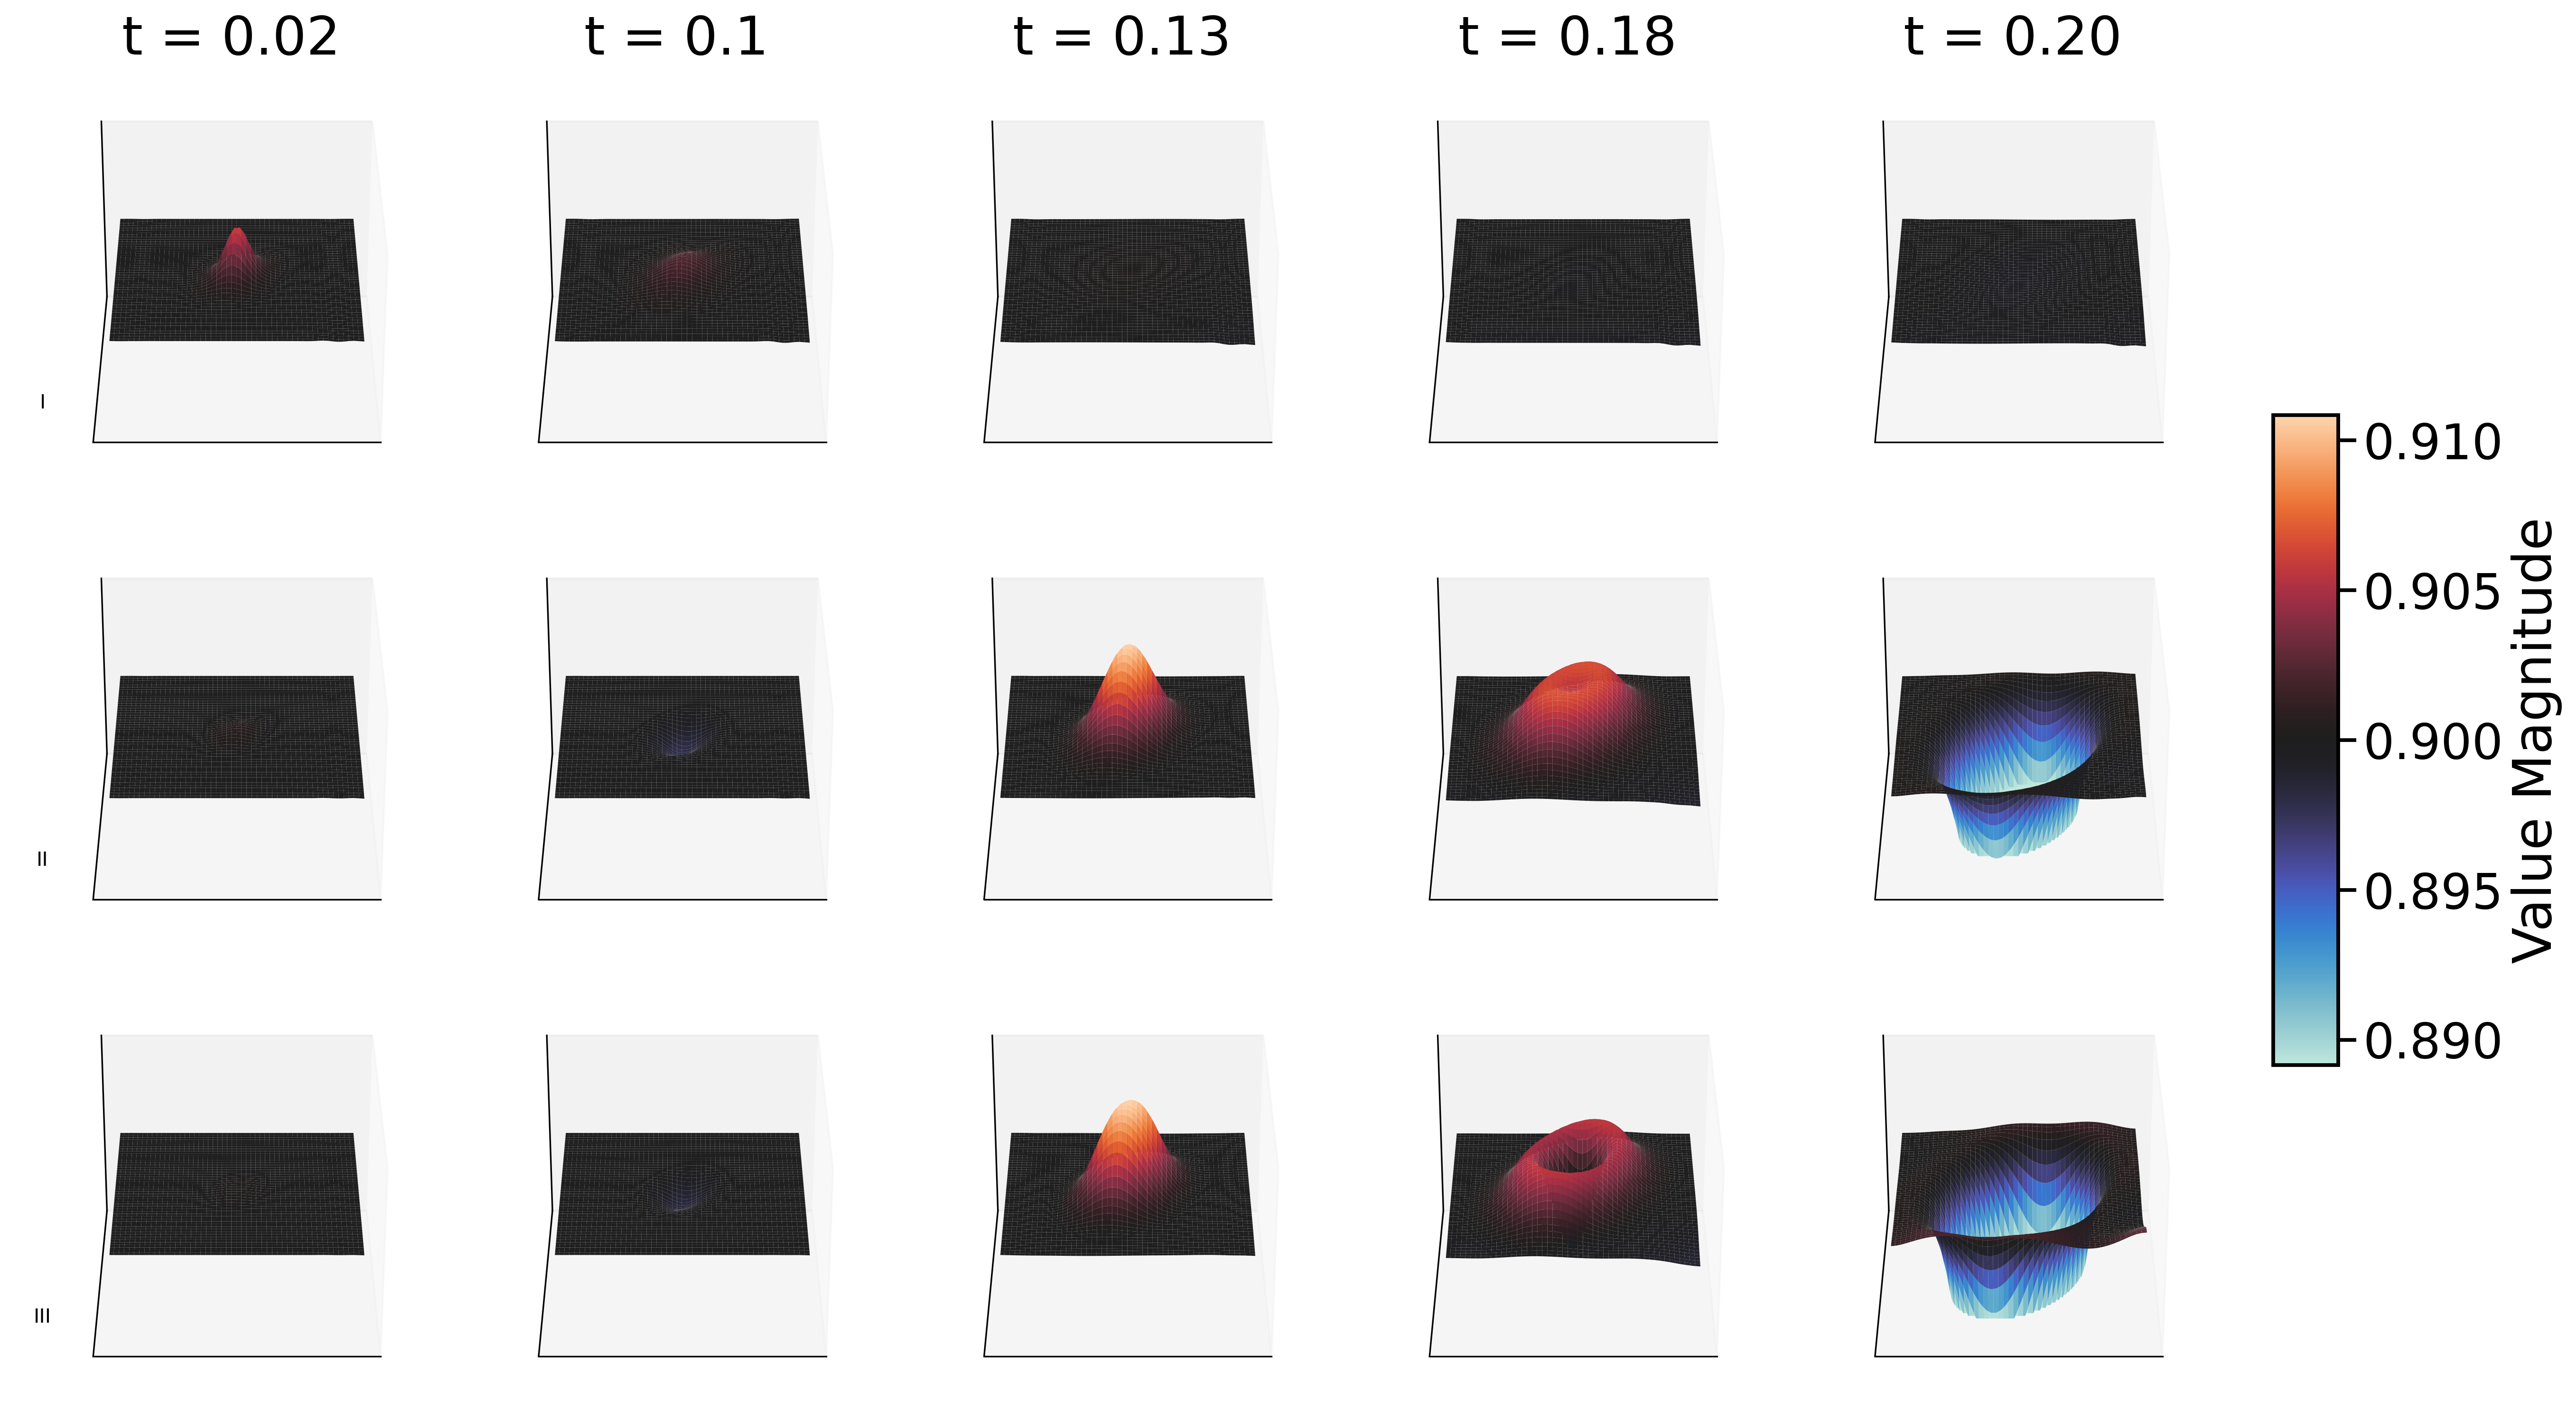

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.ndimage import zoom
import numpy as np

# Define constants
indices = [8 * 5 + 2 - 1, 8 * 4 + 5, 8 * 3 + 7 - 1]
titles = ['I', 'II', 'III']
times = [2, 5, 10, 12, 15]
time_titles = ['t = 0.02', 't = 0.1', 't = 0.13', 't = 0.18', 't = 0.20']
color = 'icefire'
ntime = len(times)  # Number of time steps
nrows = len(indices)  # Number of rows (locations)
ncols = ntime         # Number of columns (time steps)
nodes = 50  # Original grid size

scales = [1, 10, 10]

# Create mesh grid for plotting
x = np.linspace(0, 1, nodes * 5)  # Adjust for high-res interpolation
y = np.linspace(0, 1, nodes * 5)
X, Y = np.meshgrid(x, y)

# Create the figure and axes
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10), dpi=300,
                         subplot_kw={"projection": "3d"}, constrained_layout=True)

# Set context for improved aesthetics
sns.set_context("talk", font_scale=1.5)

# Iterate over rows and columns
for j, index in enumerate(indices):
    plotsol = solutions_gd_flat[index]

    center = 0.9  # Center around steady state
    delta = np.max(np.abs(plotsol[scales[j]] - center))  # Deviation from center
    vmin = center - delta
    vmax = center + delta

    for i in range(ntime):
        ax = axes[j, i]
        square = plotsol[times[i]].reshape(nodes, nodes)

        # Interpolate to a higher resolution
        square_highres = zoom(square, zoom=5, order=1)

        # Plot 3D surface
        surf = ax.plot_surface(X, Y, np.clip(square_highres, a_min=vmin, a_max=vmax), cmap=color, vmin=vmin, vmax=vmax,
                               edgecolor='none', antialiased=True)

        # Set titles and labels
        if j == 0:  # Only set column titles in the first row
            ax.set_title(time_titles[i])

        if i == 0:  # Only set row labels in the first column
            ax.set_ylabel(f'{titles[j]}')

        # Set view angle for better visibility
        ax.view_init(elev=30, azim=90)

        # Remove axis ticks for cleaner look
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

        ax.set_zlim(vmin, vmax)
        # ax.set_zscale('log')

# Add a colorbar to the figure
fig.colorbar(surf, ax=axes[:, -1], shrink=0.6, aspect=10, pad=0.1, location='right', label="Value Magnitude")

# Display the final 3D plot grid
plt.show()

0.0003 -0.0003
0.0003 -0.0003
0.0003 -0.0003


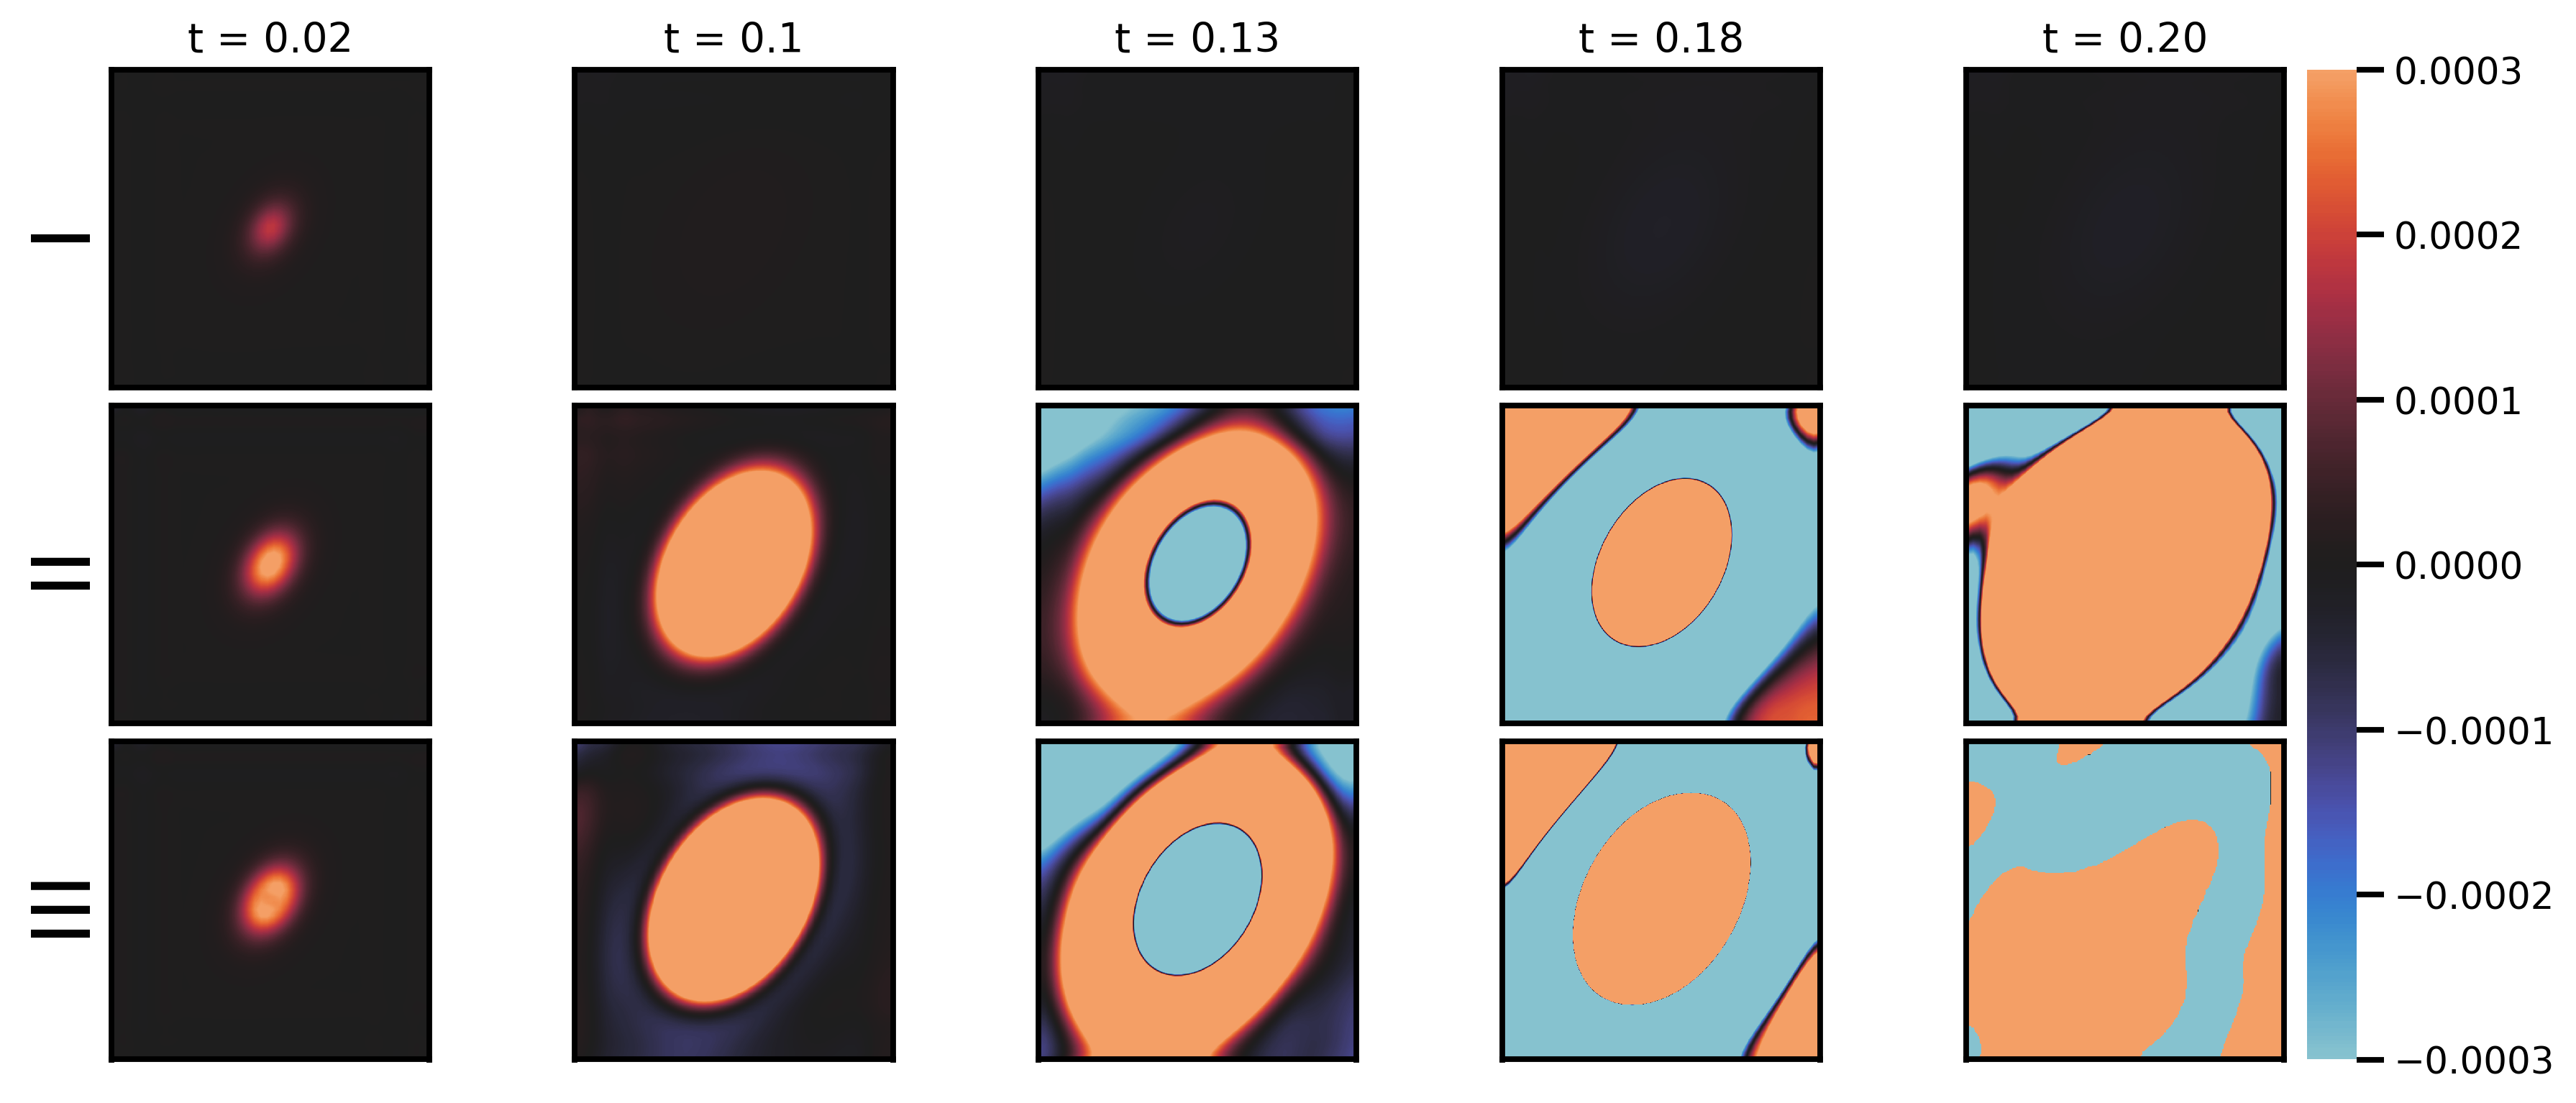

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import zoom
import matplotlib.colors as mcolors

# Function to truncate a colormap
def truncate_colormap(cmap, min_val=0.1, max_val=0.9, n=256):
    """Truncate a colormap to remove values outside [min_val, max_val]."""
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name}, {min_val}, {max_val})",
        cmap(np.linspace(min_val, max_val, n))
    )
    return new_cmap

# Load 'icefire' colormap from Seaborn
icefire = sns.color_palette("icefire", as_cmap=True)

# Truncate the colormap to exclude white ends
color = truncate_colormap(icefire, min_val=0.075, max_val=0.925)

# Define constants
indices = [8 * 5 + 2 - 1, 8 * 4 + 5, 8 * 3 + 7 - 1]
titles = ['I', 'II', 'III']
times = [2, 10, 13, 18, 20]
time_titles = ['t = 0.02', 't = 0.1', 't = 0.13', 't = 0.18', 't = 0.20']
ntime = len(times)  # Number of time steps
nrows = len(indices)  # Number of rows (locations)
ncols = ntime         # Number of columns (time steps)
nodes = 50
scale = [2, 7, 7]

# Create a single 3x3 grid of subplots with higher DPI
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5), dpi=300, constrained_layout=True)

# Set context for improved aesthetics
sns.set_context("talk", font_scale=0.75)

# Iterate over rows and columns
for j, index in enumerate(indices):
    plotsol = solutions_gd_flat[index] - np.ones_like(solutions_gd_flat[index]) * 0.9

    vmax = 0.0003#np.max(np.abs(plotsol[scale[j]]))
    vmin = -0.0003 #-vmax

    print(vmax, vmin)

    for i in range(ntime):
        ax = axes[j, i]
        square = plotsol[times[i]].reshape(nodes, nodes)
        
        # Interpolate the data to double resolution (linear interpolation)
        square_highres = zoom(square, zoom=5, order=1)

        # Plot the interpolated data
        img = ax.imshow(square_highres, cmap=color, origin='lower', vmin=(vmin), vmax=(vmax))

        # Set titles and labels
        if j == 0:  # Only set column titles in the first row
            ax.set_title(time_titles[i])

        if i == 0:  # Only set row labels in the first column
            ax.set_ylabel(f'{titles[j]}')

        # Remove axis ticks for cleaner look
        ax.set_xticks([])
        ax.set_yticks([])

cbar = fig.colorbar(img, ax=axes, shrink=1, aspect=20, pad=0.01, location='right')
cbar.outline.set_edgecolor(None)
cbar.outline.set_linewidth(0)

# Display the final high-resolution plot
plt.show()

##### Thermo Measures

In [729]:
def compute_energy_norm(state, grid_size=50, h=0.06):
    """
    Computes the energy norm of a 2D state using discrete L2 norm and gradient norm.
    
    Parameters:
    - state: 1D numpy array of length grid_size^2 (e.g., 2500)
    - grid_size: number of grid points along one axis (default 50)
    - h: grid spacing (default 0.06)
    
    Returns:
    - energy: scalar value of the energy norm
    """
    # Reshape to 2D grid
    x = state.reshape((grid_size, grid_size))

    try:
        xsq = x**2
    except OverflowError:
        print("Overflow error encountered in squaring operation.")
        return np.inf
    
    # Compute L2 norm squared
    l2_norm_sq = h**2 * np.sum(x**2)
    
    # Compute gradients using central differences (exclude boundaries)
    dx = (x[2:, 1:-1] - x[:-2, 1:-1]) / (2 * h)
    dy = (x[1:-1, 2:] - x[1:-1, :-2]) / (2 * h)
    
    # Gradient norm squared
    grad_norm_sq = h**2 * np.sum(dx**2 + dy**2)

    # Total energy norm
    energy = l2_norm_sq + grad_norm_sq
    return energy

def compute_shannon_entropy(state, grid_size=50):
    """
    Computes the Shannon entropy of a normalized 2D state.
    
    Parameters:
    - state: 1D numpy array of length grid_size^2 (e.g., 2500)
    - grid_size: number of grid points along one axis (default 50)
    
    Returns:
    - entropy: scalar value of the Shannon entropy
    """
    mini = np.min(state)
    state = state - mini  # Shift to non-negative values
    total = np.sum(state)
    
    if total == 0:
        # Return the max entropy for a uniform distribution over the grid
        max_entropy = np.log(grid_size**2)
        return max_entropy

    # Normalize to probability distribution
    p = state / total

    # Mask zero entries to avoid log(0)
    p_nonzero = p[p > 0]

    entropy = -np.sum(p_nonzero * np.log(p_nonzero))
    return entropy
def get_free_energy(solutions, temperature, max_timesteps, ds=ds, gammas=gammas):

    free_energy = np.zeros((len(ds), len(gammas), max_timesteps))
    entropies = np.zeros((len(ds), len(gammas), max_timesteps))
    energies = np.zeros((len(ds), len(gammas), max_timesteps))
    l2 = np.zeros((len(ds), len(gammas), max_timesteps))

    for i in range(len(ds)):
        for j in range(len(gammas)):
            for k in range(max_timesteps):

                state = solutions[i*len(gammas) + j][k]

                energy = compute_energy_norm(state)
                entropy = compute_shannon_entropy(state)
                l2_norm_sq = 0.06**2 * np.sum(state**2)

                l2[i, j, k] = np.sqrt(l2_norm_sq)
                entropies[i, j, k] = entropy
                energies[i, j, k] = energy

                free_energy[i,j,k] = energy - temperature * entropy

    return entropies, energies, l2

In [784]:
entropies, energies, l2 = get_free_energy(solutions_gd_flat, 0, max_timesteps=30)
print(entropies.shape)

#smooth entropies by making entries that are =0 the linear interpolation of the two closest non-zero entries

def smooth(entropies):
    smoothed = entropies.copy()
    for i in range(entropies.shape[0]):
        for j in range(entropies.shape[1]):
            for k in range(entropies.shape[2]):
                if entropies[i, j, k] == 0 or np.isnan(entropies[i, j, k]):
                    # Find the closest non-zero entries
                    left = k - 1
                    right = k + 1
                    while left >= 0 and (entropies[i, j, left] == 0 or np.isnan(entropies[i, j, left])):
                        left -= 1
                    while right < entropies.shape[2] and (entropies[i, j, right] == 0 or np.isnan(entropies[i, j, right])):
                        right += 1
                    
                    # If both sides are valid, interpolate
                    if left >= 0 and right < entropies.shape[2]:
                        smoothed[i, j, k] = (entropies[i, j, left] + entropies[i, j, right]) / 2
    return smoothed

entropies = smooth(entropies)
energies = smooth(energies)

entropies += 1e-10  # Avoid log(0) in entropy calculation

ds = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
gammas = [10, 25, 50, 100, 150, 200, 250, 500]

print(np.max(entropies))
print(np.min(entropies))
#9 ds, 8 gammas, 11 time steps

(9, 8, 30)
7.824046010956292
1e-10


/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/224455845.py:17: RuntimeWarning: overflow encountered in square
  xsq = x**2
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/224455845.py:23: RuntimeWarning: overflow encountered in square
  l2_norm_sq = h**2 * np.sum(x**2)
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/224455845.py:30: RuntimeWarning: overflow encountered in square
  grad_norm_sq = h**2 * np.sum(dx**2 + dy**2)
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/224455845.py:79: RuntimeWarning: overflow encountered in square
  l2_norm_sq = 0.06**2 * np.sum(state**2)


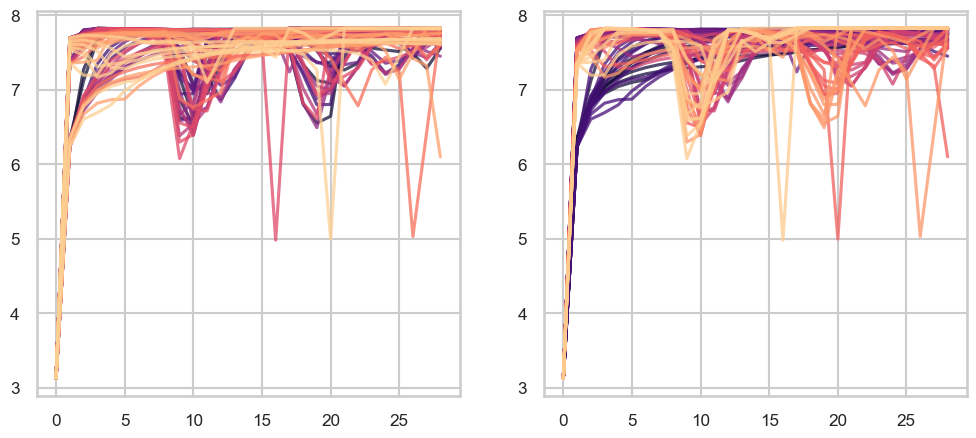

In [785]:
#Plot the entropy over time
dcolors = sns.color_palette("magma", n_colors=len(ds))
gcolors = sns.color_palette("magma", n_colors=len(gammas))

alpha1 = 0.75
# entropies = entropies[:, :, :-1]  - entropies[0,0,:-1]  # Normalize by the first entry

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
for i in range(len(ds)):
    plt.plot(entropies[i, :, :-1].T, color=dcolors[i], alpha = alpha1)
# for i in range(len(ds)):
#     plt.plot(np.mean(entropies[i, :, :-1].T, axis=1), color=dcolors[i], linewidth=2)

# plt.yscale('log')
plt.subplot(1,2,2)
for j in range(len(gammas)):
    plt.plot(entropies[:, j, :-1].T, color=gcolors[j], alpha = alpha1)
# for j in range(len(gammas)):
#     plt.plot(np.mean(entropies[:, j, :-1].T, axis=1), color=gcolors[j], linewidth=2)
# plt.yscale('log')
plt.show()

In [790]:
import numpy as np
import matplotlib.pyplot as plt

def get_gradients(metric, ds, gammas):
    """
    Compute ∂metric/∂d and ∂metric/∂gamma using finite differences.
    """
    n_d, n_g, n_t = metric.shape
    dSdd = np.zeros_like(metric)
    dSdg = np.zeros_like(metric)

    for k in range(n_t):
        for i in range(n_d):
            for j in range(n_g):
                # Derivative wrt d
                if i == 0:
                    delta_d = ds[1] - ds[0]
                    dSdd[i, j, k] = (metric[i+1, j, k] - metric[i, j, k]) / delta_d
                elif i == n_d - 1:
                    delta_d = ds[-1] - ds[-2]
                    dSdd[i, j, k] = (metric[i, j, k] - metric[i-1, j, k]) / delta_d
                else:
                    delta_d = ds[i+1] - ds[i-1]
                    dSdd[i, j, k] = (metric[i+1, j, k] - metric[i-1, j, k]) / delta_d

                # Derivative wrt gamma
                if j == 0:
                    delta_g = gammas[1] - gammas[0]
                    dSdg[i, j, k] = (metric[i, j+1, k] - metric[i, j, k]) / delta_g
                elif j == n_g - 1:
                    delta_g = gammas[-1] - gammas[-2]
                    dSdg[i, j, k] = (metric[i, j, k] - metric[i, j-1, k]) / delta_g
                else:
                    delta_g = gammas[j+1] - gammas[j-1]
                    dSdg[i, j, k] = (metric[i, j+1, k] - metric[i, j-1, k]) / delta_g

    return dSdd, dSdg

def deviation(entropies, ds, gammas, dt=0.01):
    """
    Compute Fisher information matrix, determinant, and trace over (d, gamma, t)
    """
    dSdd, dSdg = get_gradients(entropies, ds, gammas)

    n_d, n_g, n_t = entropies.shape
    fisher_mats = np.zeros((n_d, n_g, n_t, 2, 2))
    dinfo = np.zeros((n_d, n_g, n_t,))
    ginfo = np.zeros((n_d, n_g, n_t,))

    for i in range(n_d):
        for j in range(n_g):
            for k in range(n_t):
                dd = dSdd[i, j, k]
                dg = dSdg[i, j, k]
                fisher_mats[i, j, k] = np.array([
                    [dd**2, dd * dg],
                    [dd * dg, dg**2]
                ])# / dt  # Normalize by dt

                dinfo[i, j, k] = dd**2
                ginfo[i, j, k] = dg**2

    determinants = np.linalg.det(fisher_mats)
    traces = np.trace(fisher_mats, axis1=3, axis2=4)

    return determinants, traces, dinfo, ginfo

# Compute and plot

dets, traces, dinfo, ginfo = deviation(entropies, ds, gammas)

_, _, dinfoE, ginfoE = deviation(energies, ds, gammas)

dinfo = dinfo[:,:,2:]
ginfo = ginfo[:,:,2:]

ginfoE = ginfoE[:,:,2:]
dinfoE = dinfoE[:,:,2:]

mean_dinfo = np.mean(dinfo, axis = (0,1))
std_dinfo = np.std(dinfo, axis = (0,1))

mean_dinfoE = np.mean(dinfoE, axis = (0,1))
std_dinfoE = np.std(dinfoE, axis = (0,1))

mean_ginfo = np.mean(ginfo, axis = (0,1))
std_ginfo = np.std(ginfo, axis = (0,1))

mean_ginfoE = np.mean(ginfoE, axis = (0,1))
std_ginfoE = np.std(ginfoE, axis = (0,1))

/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/2700687894.py:18: RuntimeWarning: invalid value encountered in scalar subtract
  dSdd[i, j, k] = (metric[i+1, j, k] - metric[i, j, k]) / delta_d
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/2700687894.py:24: RuntimeWarning: invalid value encountered in scalar subtract
  dSdd[i, j, k] = (metric[i+1, j, k] - metric[i-1, j, k]) / delta_d
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/2700687894.py:56: RuntimeWarning: invalid value encountered in scalar multiply
  [dd**2, dd * dg],
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/2700687894.py:57: RuntimeWarning: invalid value encountered in scalar multiply
  [dd * dg, dg**2]
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/2700687894.py:57: RuntimeWarning: overflow encountered in scalar power
  [dd * dg, dg**2]
/var/folders/px/b7h6xd3j2kjg5hjgqtx6p4jr0000gn/T/ipykernel_7658/2700687894.py:61: RuntimeWarning: ove

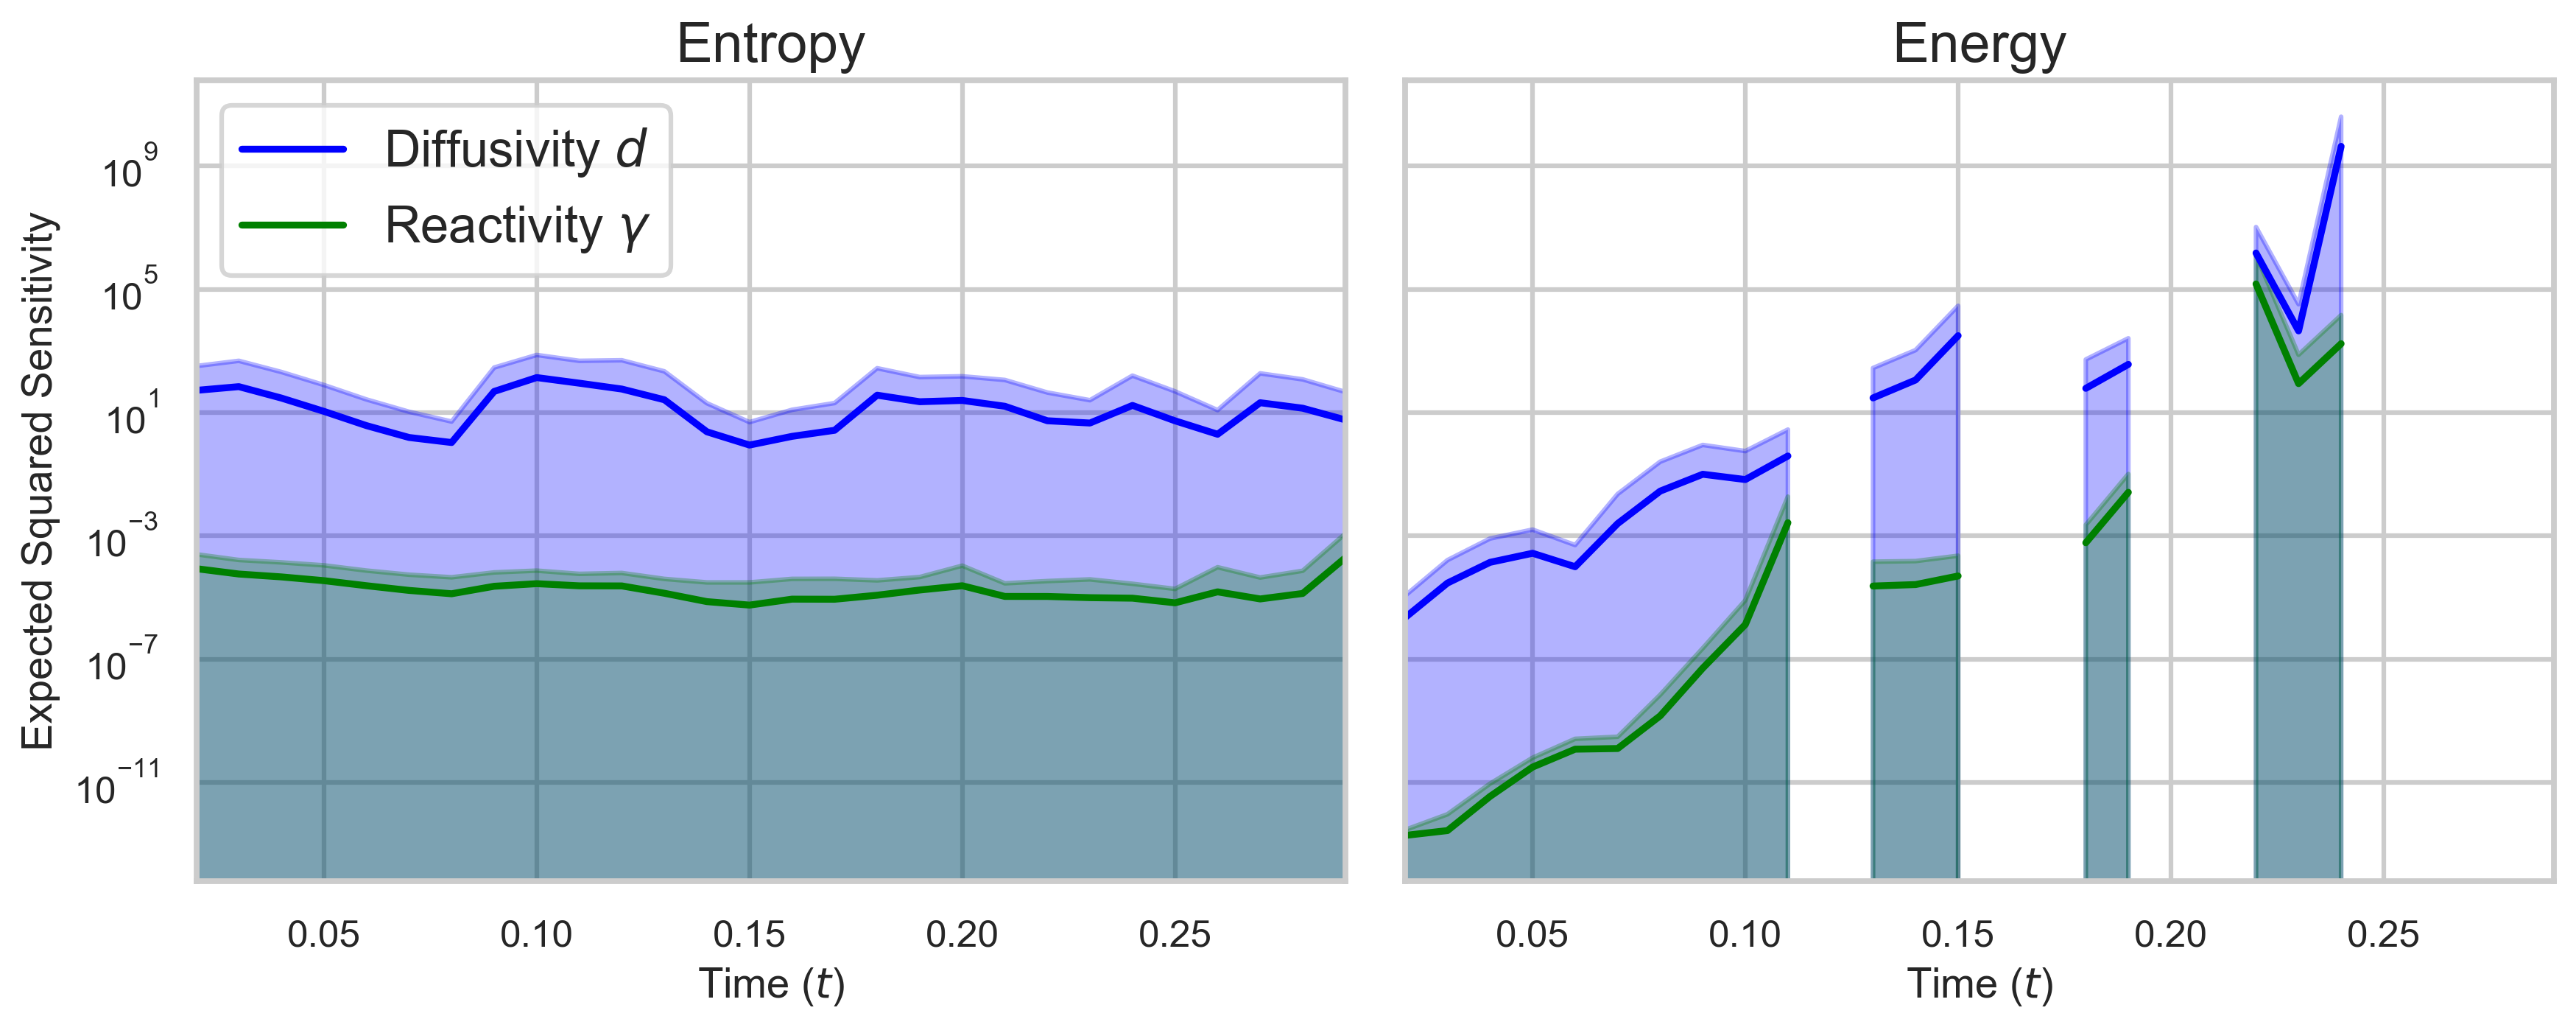

In [795]:
# Create side-by-side plots with shared y-axis
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi = 300)

sns.set_context("talk", font_scale=1)

times = np.arange(len(mean_dinfo)) * 0.01  + 0.02  # Adjust for time steps starting from 0.02

# --- Plot 1: Entropy Fisher Information ---
axs[0].plot(times, mean_dinfo, label=r'Diffusivity $d$', color='blue')
axs[0].plot(times, mean_ginfo, label=r'Reactivity $\gamma$', color='green')

axs[0].fill_between(times, 
                    mean_dinfo - std_dinfo, 
                    mean_dinfo + std_dinfo, 
                    alpha=0.3, color='blue')

axs[0].fill_between(times, 
                    mean_ginfo - std_ginfo, 
                    mean_ginfo + std_ginfo, 
                    alpha=0.3, color='green')

axs[0].set_xlabel('Time ($t$)')
# axs[0].set_xticks(times[::2])  # Show every second time step for clarity
axs[0].set_ylabel('Expected Squared Sensitivity')
axs[0].set_title('Entropy')
axs[0].set_yscale('log')
axs[0].legend(loc='upper left')

# --- Plot 2: Energy Fisher Information ---
axs[1].plot(times, mean_dinfoE, label=r'$\partial E / \partial d$', color='blue')
axs[1].plot(times, mean_ginfoE, label=r'$\partial E / \partial \gamma$', color='green')

axs[1].fill_between(times,
                    mean_dinfoE - std_dinfoE, 
                    mean_dinfoE + std_dinfoE, 
                    alpha=0.3, color='blue')

axs[1].fill_between(times, 
                    mean_ginfoE - std_ginfoE, 
                    mean_ginfoE + std_ginfoE, 
                    alpha=0.3, color='green')

axs[1].set_xlabel('Time ($t$)')
# axs[1].set_xticks(times[::2])  # Show every second time step for clarity
axs[1].set_title('Energy')
axs[1].set_yscale('log')

for i in range(2):
    axs[i].set_xlim(times[0], times[-1])

plt.tight_layout()
plt.show()

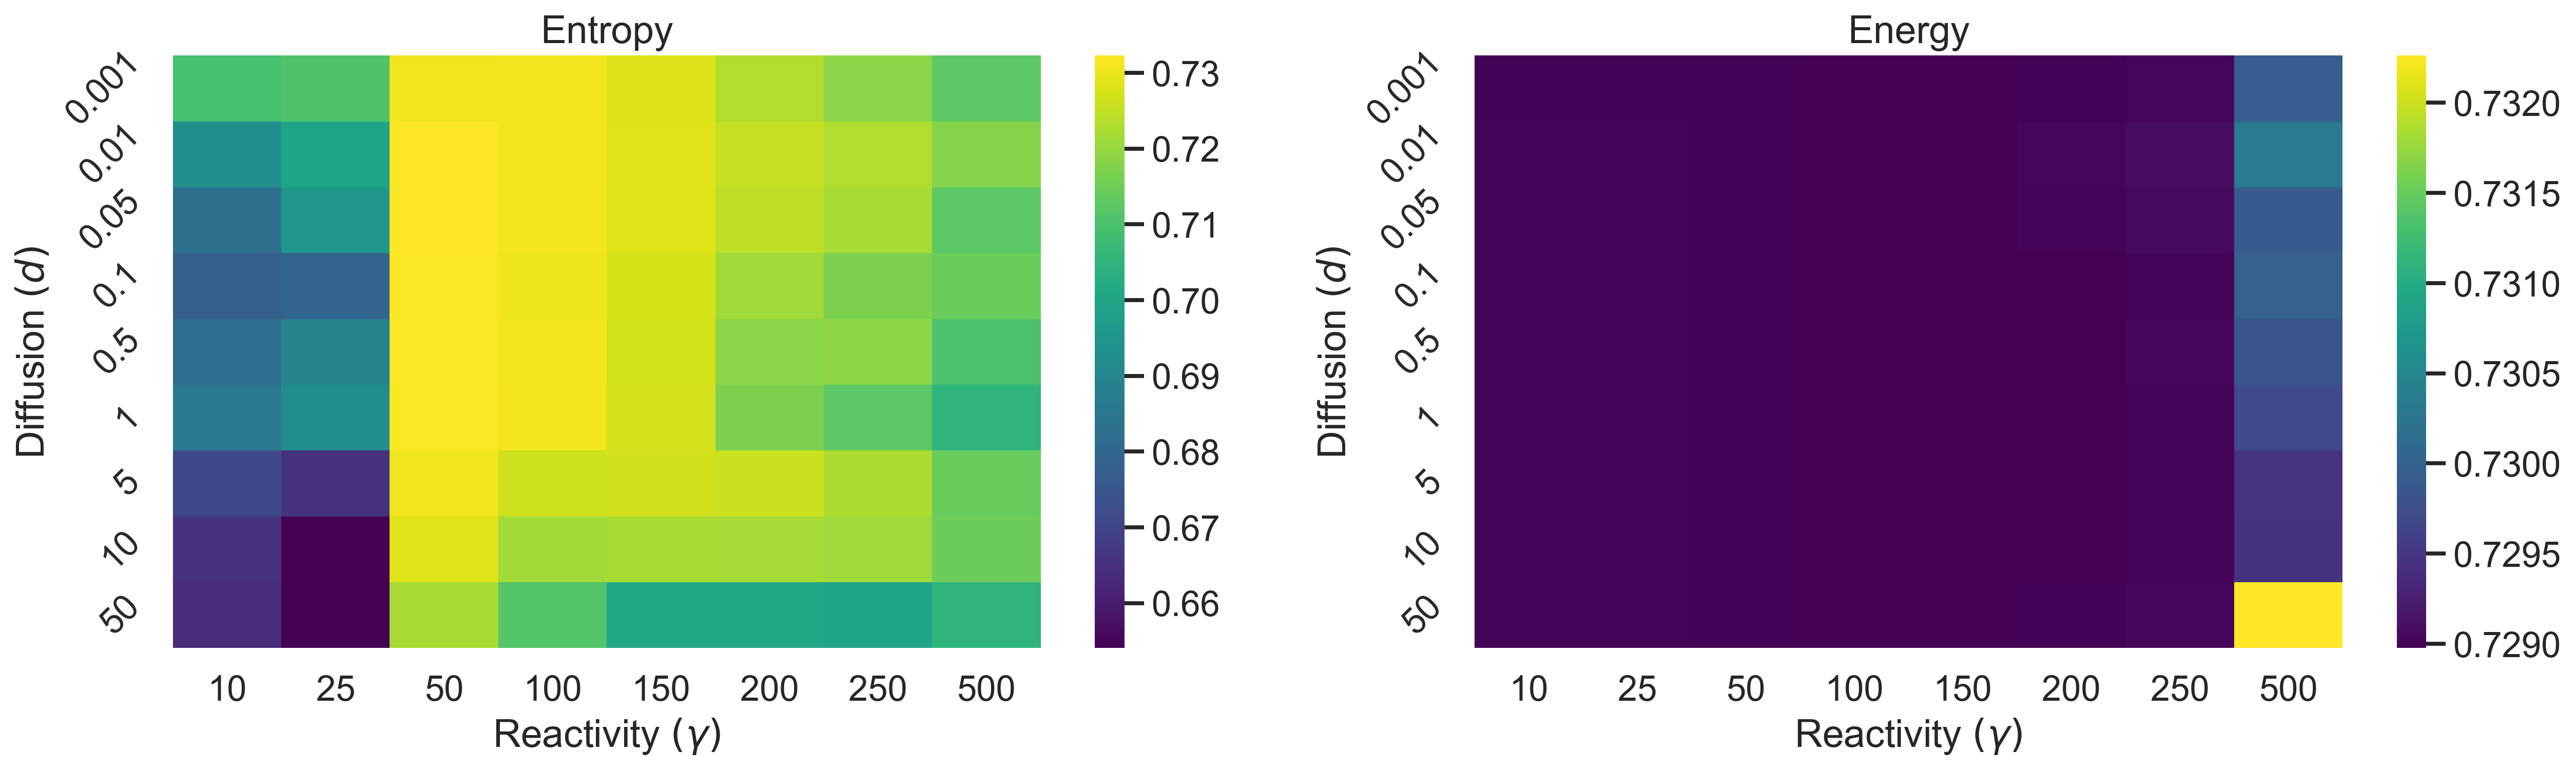

In [831]:
dt = 0.01
maxtime = 10  # number of time steps to include

# Compute total entropy up to maxtime (time axis is last, axis=2)
total_entropy = np.sum(entropies[:, :, :maxtime], axis=2) * dt  # shape (9,8)

# Initialize total_energy array with correct shape
total_energy = np.zeros_like(total_entropy)  # shape (9,8)

# Threshold value
energy_threshold = 1e6

# Vectorized energy accumulation with threshold mask
for k in range(maxtime):
    mask = energies[:, :, k] <= energy_threshold
    total_energy += energies[:, :, k] * dt * mask  # accumulate only valid energy values

fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)
sns.set_context("talk", font_scale=1)

# Subplot 1: Heatmap for integral_entropy_change
sns.heatmap(
    total_entropy, ax=axs[0], cmap="viridis", 
    xticklabels=gammas, yticklabels=ds, 
    #cbar_kws={'label': 'Log Normalized Entropy'}
)
axs[0].set_xlabel("Reactivity $(\gamma)$")
axs[0].set_ylabel("Diffusion $(d)$")
axs[0].set_title("Entropy")
axs[0].tick_params(axis='y', labelrotation=45)  # Rotate the y-axis tick labels by 45 degrees

# Subplot 2: Heatmap for integral_gradient_change
sns.heatmap(
    total_energy, ax=axs[1], cmap="viridis", 
    xticklabels=gammas, yticklabels=ds, 
   #cbar_kws={'label': 'Log Normalized Gradient'}
)
axs[1].set_xlabel("Reactivity $(\gamma)$")
axs[1].set_ylabel("Diffusion $(d)$")
axs[1].set_title("Energy")
axs[1].tick_params(axis='y', labelrotation=45)  # Rotate the y-axis tick labels by 45 degrees